<a href="https://colab.research.google.com/github/RvXp/Topicos-Especiais-em-IA-LLM/blob/main/Transformer_Encoder_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercício

O objetivo deste exercício é treinar um modelo que seja capaz de aprender as características do conteúdo do seu conjunto de documento.

Para isso, você deve:

1.   carregar o seu conjunto de documentos
2.   treinar e usar (ou carregar) um tokenizador
3.   fazer treino de um modelo encoder-only

### Teste do modelo treino

1. Preparar 2 sub-conjuntos de amostras do conjunto original documentos de forma que internamente cada sub-conjunto trata sobre apenas um assunto e os subconjuntos são sobre diferentes assuntos
2. Executar modelo encoder only que você treino para obter embedding semântico para cada documento
3. Aplicar técnica de redução de dimensionalidade e fazer gráfico que mostrará que documentos mais similares em conteúdo estarão em regiões mais próximas.



In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from datasets import load_dataset
import re

def clean_ascii(text):
    text = text.encode("ascii", errors="ignore").decode()
    return re.sub(r"[^A-Za-z0-9 .,:;!?'\-]", "", text)

# Carregando frases
import os
caminho_do_arquivo = '/content/drive/MyDrive/IA - LLM/frases.txt'

# 1. CARREGAMENTO E LIMPEZA DOS DOCUMENTOS
if os.path.exists(caminho_do_arquivo):
    with open(caminho_do_arquivo, 'r', encoding='utf-8') as f:
        # Lemos as linhas e aplicamos a limpeza
        documentos = [clean_ascii(linha.strip()) for linha in f.readlines() if len(linha.strip()) > 0]
    print(f"Sucesso! {len(documentos)} frases carregadas do Google Drive.")
else:
    print("ERRO: O arquivo não foi encontrado no caminho especificado. Verifique se o nome e a pasta estão corretos.")

print("Total de frases carregadas:", len(documentos))
print("Amostra:", documentos[:5])

Sucesso! 753 frases carregadas do Google Drive.
Total de frases carregadas: 753
Amostra: ['O homem  a medida de todas as coisas, das coisas que so, enquanto so, das coisas que no so, enquanto no so.', 'S sei que nada sei.', 'A vida no examinada no vale a pena ser vivida.', 'Ningum entra no mesmo rio duas vezes, pois tudo flui e nada permanece.', 'O ser  e o no-ser no .']


In [6]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace
import random
import re

##### Insira aqui o código para treinar o seu TOKENIZER
# Defina o seu tokenizador
tokenizer = Tokenizer(WordLevel(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = WordLevelTrainer(
    vocab_size=2000, # Aumentado levemente para cobrir o vocabulário filosófico
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]", "[MASK]"]
)
# Treino do tokenizador
tokenizer.train_from_iterator(documentos, trainer)

def encode(text):
    ids = tokenizer.encode("[BOS] " + text + " [EOS]").ids
    return torch.tensor(ids, dtype=torch.long)

def decode(ids):
    return tokenizer.decode(ids.tolist())

vocab_size = tokenizer.get_vocab_size()
pad_token_id = tokenizer.token_to_id("[PAD]")
mask_token_id = tokenizer.token_to_id("[MASK]")

In [7]:
class EncoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, num_layers=3, max_len=64):
        super().__init__()
        self.max_len = max_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=256,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def initial_hidden_state(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = self.token_emb(x) + self.pos_emb(pos)
        return h

    def forward(self, x):
        h = self.initial_hidden_state(x)
        out = self.encoder(h)
        logits = self.lm_head(out)
        return logits

In [8]:
def get_semantic_embedding(text, model, max_len = 20):
    model.eval()

    with torch.no_grad():
        # Tokenizar texto
        x = encode(text).to(device)
        x = x[:max_len]

        # Uaar dimensão de batch
        x = x.unsqueeze(0) # Shape: (1, T)

        # Aplicar positional encoding e embedding
        h = model.initial_hidden_state(x)

        # Processa com camadas de encoding mas *não* usar lm_head
        out = model.encoder(h)

        # Aplicar pooling, ou seja, média dos estados ao longo da sequência (dim 1)
        embedding = out.mean(dim=1)

        return embedding.detach().cpu().numpy()

In [9]:
# Função auxiliar para gerar batches de exemplos para treino
def sample_batch(batch_size=16, max_len=20):
    batch = random.sample(documentos, batch_size)
    tokenized = [encode(t) for t in batch]

    max_t = min(max(len(x) for x in tokenized), max_len)
    padded = []

    for x in tokenized:
        x = x[:max_t]
        pad_len = max_t - len(x)
        if pad_len > 0:
            x = torch.cat([x, torch.full((pad_len,), pad_token_id, dtype=torch.long)])
        padded.append(x)

    return torch.stack(padded)

def apply_mlm_mask(batch, mask_prob=0.15):
    inputs = batch.clone()
    labels = batch.clone()

    # Mascarar 15% dos tokens (exceto PAD/Especiais)
    probs = torch.rand(batch.shape, device=batch.device)
    is_special = (batch == pad_token_id) | (batch == tokenizer.token_to_id("[BOS]")) | (batch == tokenizer.token_to_id("[EOS]"))
    mask_indices = (probs < mask_prob) & (~is_special)

    inputs[mask_indices] = mask_token_id

    # Calcular loss apenas nos mascarados (ignorar o resto)
    labels[~mask_indices] = -100

    return inputs, labels


In [10]:
################################
device = "cuda" if torch.cuda.is_available() else "cpu"
model = EncoderOnlyTransformer(vocab_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
#################################

steps = 5000

for step in range(1, steps + 1):
    model.train()
    batch = sample_batch().to(device)
    inputs, labels = apply_mlm_mask(batch)

    logits = model(inputs)

    loss = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        labels.reshape(-1),
        ignore_index=-100
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        print(f"[step {step}] loss={loss.item():.4f}")

print("Training completed.")

[step 100] loss=6.0983
[step 200] loss=5.8133
[step 300] loss=5.1675
[step 400] loss=4.1027
[step 500] loss=6.0659
[step 600] loss=5.1928
[step 700] loss=5.2373
[step 800] loss=5.4939
[step 900] loss=4.3019
[step 1000] loss=4.2378
[step 1100] loss=4.6200
[step 1200] loss=4.5183
[step 1300] loss=3.7980
[step 1400] loss=4.7927
[step 1500] loss=4.9427
[step 1600] loss=3.0829
[step 1700] loss=4.3520
[step 1800] loss=4.1379
[step 1900] loss=4.9862
[step 2000] loss=4.9768
[step 2100] loss=4.7151
[step 2200] loss=4.9062
[step 2300] loss=4.6186
[step 2400] loss=4.6978
[step 2500] loss=5.3123
[step 2600] loss=3.7525
[step 2700] loss=4.2516
[step 2800] loss=4.5421
[step 2900] loss=4.2913
[step 3000] loss=4.5431
[step 3100] loss=3.7533
[step 3200] loss=4.7776
[step 3300] loss=4.1620
[step 3400] loss=3.2590
[step 3500] loss=3.4881
[step 3600] loss=4.1044
[step 3700] loss=3.2166
[step 3800] loss=3.9564
[step 3900] loss=4.1285
[step 4000] loss=3.2219
[step 4100] loss=3.9750
[step 4200] loss=4.0306
[

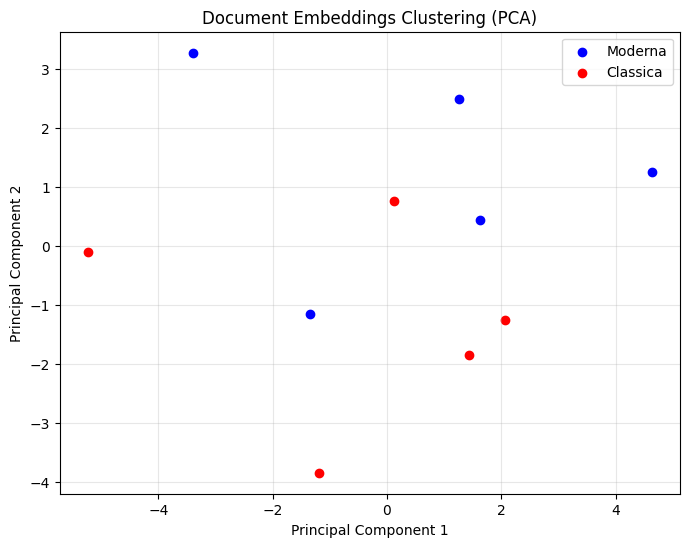

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Define sample documents representing distinct topics
frases_classicas = [
    "So sei que nada sei.",
    "O homem e um animal politico.",
    "A virtude e o unico bem.",
    "Ninguem entra no mesmo rio duas vezes.",
    "A alma e a forma do corpo."
]

frases_modernas = [
    "Penso, logo existo.",
    "Deus esta morto e nos o matamos.",
    "A existencia precede a essencia.",
    "O homem esta condenado a ser livre.",
    "O inferno sao os outros."
]
all_docs = frases_classicas + frases_modernas
labels = ["Classica"] * len(frases_classicas) + ["Moderna"] * len(frases_modernas)

# 2. Extract embeddings
embeddings = []
for doc in all_docs:
    # get_embedding returns shape (1, d_model), take [0] to get (d_model,)
    emb = get_semantic_embedding(doc, model)
    embeddings.append(emb[0])

X = np.array(embeddings)

# 3. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 4. Plot
plt.figure(figsize=(8, 6))
unique_labels = list(set(labels))
colors = ['blue', 'red']

for i, label in enumerate(unique_labels):
    indices = [j for j, x in enumerate(labels) if x == label]
    plt.scatter(X_pca[indices, 0], X_pca[indices, 1], c=colors[i], label=label)

plt.title("Document Embeddings Clustering (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()